# 09 - KDTree

---

In the previous notebook, we learned about the Curse of Dimensionality.

Before modern ANN algorithms like IVF and HNSW became popular,

researchers developed **KDTree** to speed up nearest neighbor search.

KDTree works very well for low-dimensional data,

but struggles as the number of dimensions increases.

##  History

Flat Index compares a query with every vector.

This guarantees the correct answer,

but becomes slow as the dataset grows.

Researchers asked:

"Can we divide the search space so we don't need to search everywhere?"

This idea led to **KDTree (K-Dimensional Tree)**.

##  Think Like a Researcher

Imagine a city.

Instead of searching every house,

you first divide the city into areas.

Then,

you search only inside one area.

KDTree follows the same idea.

It recursively divides the vector space into smaller regions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([
    [2,3],
    [5,4],
    [9,6],
    [4,7],
    [8,1],
    [7,2]
])

query = np.array([6,3])

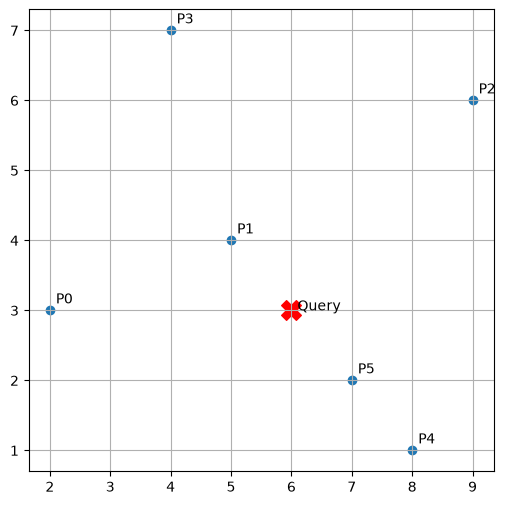

In [2]:
plt.figure(figsize=(6,6))

plt.scatter(points[:,0],points[:,1])

for i,p in enumerate(points):
    plt.text(p[0]+0.1,p[1]+0.1,f"P{i}")

plt.scatter(
    query[0],
    query[1],
    marker="X",
    color="red",
    s=200
)

plt.text(query[0]+0.1,query[1],"Query")

plt.grid()

plt.show()

## How KDTree Works

Instead of checking every point,

KDTree repeatedly splits the space.

Example:

```
All Points

↓

Split by X

↓

Split by Y

↓

Split by X

↓

...

↓

Small Regions
```

Only the relevant regions are searched.

In [3]:
from sklearn.neighbors import KDTree

tree = KDTree(points)

In [4]:
distance,index = tree.query(
    [query],
    k=3
)

distance

array([[1.41421356, 1.41421356, 2.82842712]])

In [5]:
index

array([[5, 1, 4]])

In [6]:
for i,d in zip(index[0],distance[0]):
    print(
        points[i],
        round(d,3)
    )

[7 2] 1.414
[5 4] 1.414
[8 1] 2.828


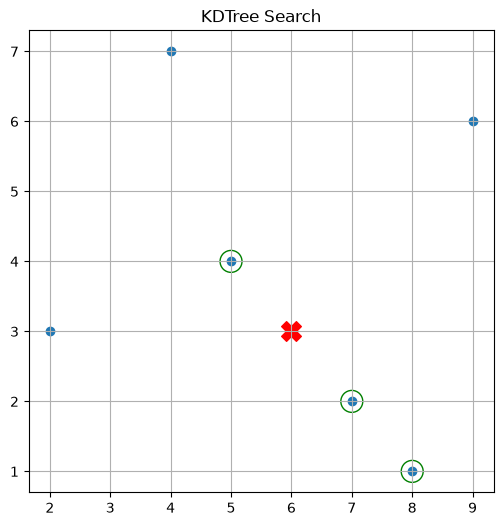

In [7]:
plt.figure(figsize=(6,6))

plt.scatter(
    points[:,0],
    points[:,1]
)

plt.scatter(
    query[0],
    query[1],
    marker="X",
    color="red",
    s=200
)

for i in index[0]:
    plt.scatter(
        points[i][0],
        points[i][1],
        s=250,
        facecolors="none",
        edgecolors="green"
    )

plt.grid()

plt.title("KDTree Search")

plt.show()

## Internal Working

KDTree stores vectors as a tree.

```
            Root

          /      \

      Left        Right

     /   \        /   \

   ...   ...   ...   ...
```

Instead of searching every node,

KDTree prunes many branches.

## Why is KDTree Faster?

Flat Index

↓

Search every vector

KDTree

↓

Skip many regions

↓

Search only promising regions

This reduces the number of distance calculations.

## Time Complexity

Flat Index

Search

↓

O(N)

KDTree

Average Search

↓

O(log N)

**Important:**

This improvement mainly applies to **low-dimensional data**.

In high-dimensional spaces,

performance can approach O(N).

## Advantages

✅ Faster than Flat Index

✅ Exact Search

✅ Good for low-dimensional data

✅ Easy to build

## Limitations

KDTree struggles when

- Dimensions become large
- Embeddings have 384D
- Embeddings have 768D
- Embeddings have 1536D

This is why modern vector databases usually prefer IVF or HNSW for embedding search.

## Applications

KDTree is commonly used for

- Geographic coordinates
- Robotics
- Computer Vision
- Scientific Computing

It is less common for modern text embedding search because of high dimensionality.

## Flat Index vs KDTree

| Flat Index | KDTree |
|------------|--------|
| Exact | Exact |
| Brute Force | Space Partitioning |
| O(N) Search | O(log N) average (low dimensions) |
| High-dimensional support | Better than KDTree for exact search in high dimensions, though still expensive |
| Small datasets | Low-dimensional datasets |

##  Summary

Today I learned

- What KDTree is
- How it partitions space
- Why it is faster
- Why it works well in low dimensions
- Why it struggles in high dimensions

## Think Like a Researcher

KDTree works well for low-dimensional data.

But modern embedding vectors have hundreds of dimensions.

Researchers asked:

"What if we don't partition the space?

What if we hash similar vectors into the same bucket?"

This idea led to

**Locality Sensitive Hashing (LSH).**